#### K-Means
```
Customer A → Cluster 1
```

#### Hierarchical Clustering
```
Customer A → Cluster 1
```

#### DBSCAN
```
Customer A → Cluster 1
```

All of these perform: **Hard Clustering**

A point belongs to one cluster only.

But many real-world situations are not that clear.

##### Example
A customer might be:
```
70% Premium Customer
30% Budget Customer
```
rather than belonging completely to one segment.

### Hard Clustering vs Soft Clustering
#### Hard Clustering
K-Means:
```
Customer A → Cluster 1
```
100% assignment.

#### Soft Clustering
GMM:
```
Customer A

Cluster 1 → 0.75
Cluster 2 → 0.20
Cluster 3 → 0.05
```
Probabilistic assignment.

This is much more realistic in many domains.

### What is a Gaussian?
A Gaussian distribution is a normal distribution.

Example:

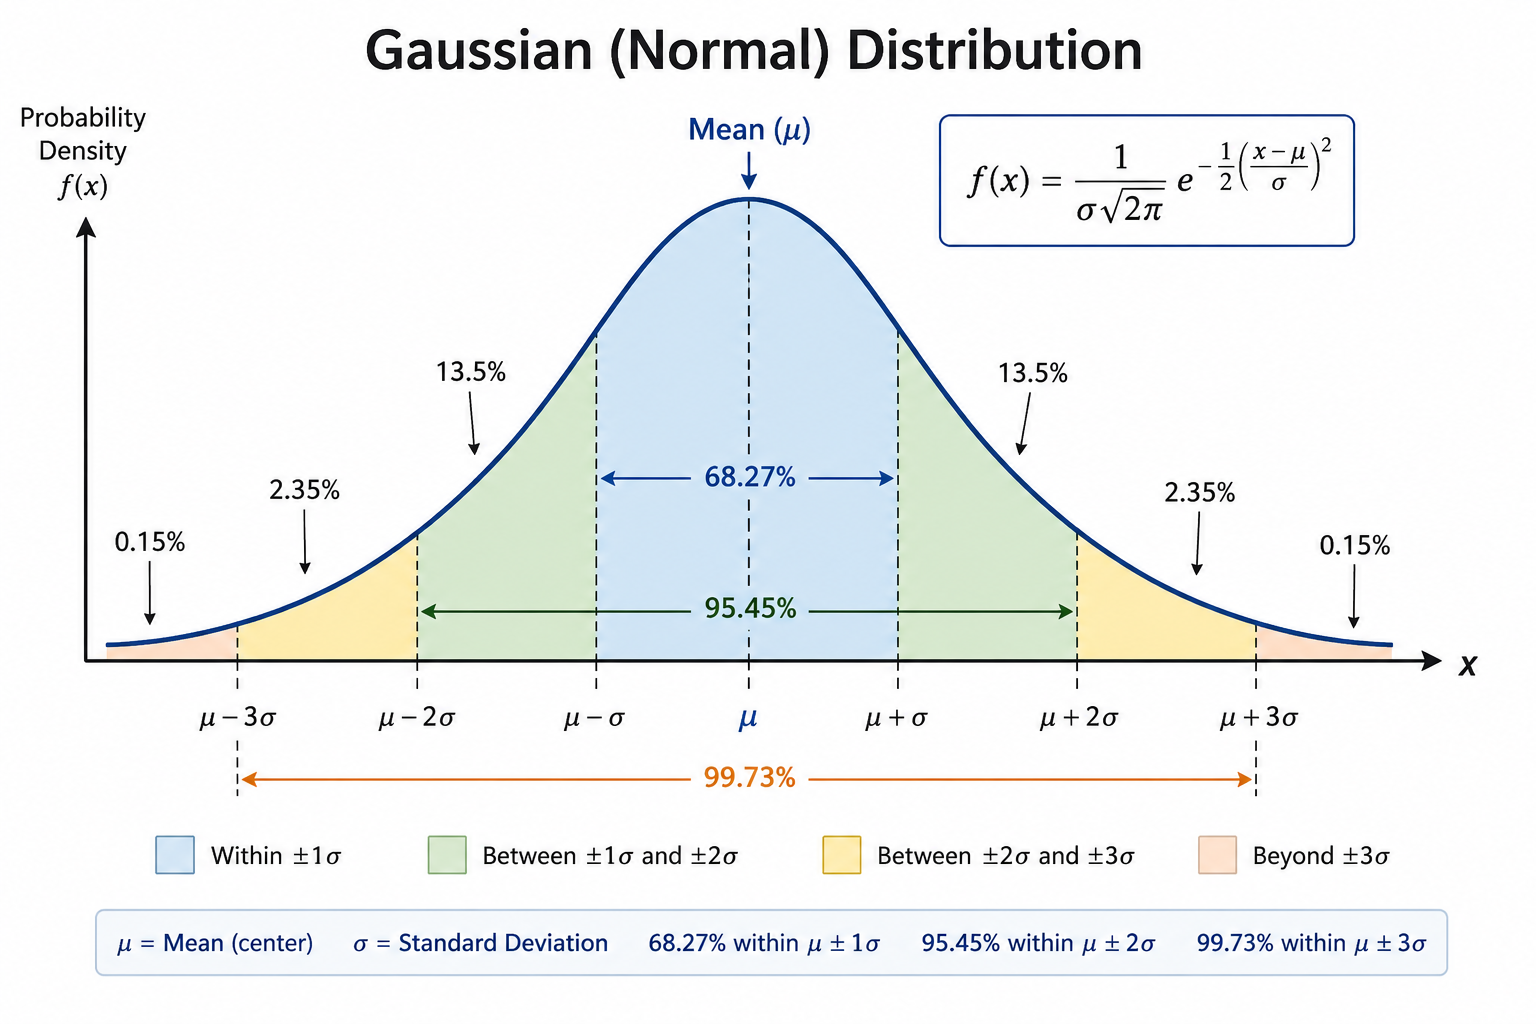

Bell-shaped curve.

### Formula
$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}
\, e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

where:
- $\mu$ = mean
- $\sigma^2$ = variance
- $\sigma$ = standard deviation


### Multivariate Gaussian
Real datasets contain multiple features.

Example:

| Income | Spending |
| ------ | -------- |
| 80k    | 40k      |
| 82k    | 42k      |

Now distribution becomes multidimensional.

Represented using:
$$
\mu
$$
Mean vector

and
$$
\sum
$$
Covariance matrix.

### Why K-Means Can Fail
K-Means assumes:
```
Clusters are spherical
```

Example
```text
OOOOOOOO
OOOOOOOO
OOOOOOOO
```

elongated cluster.

K-Means often splits incorrectly.

GMM can model:
- Elliptical clusters
- Different variances
- Different orientations

### Core Idea of GMM
Assume data comes from:
$$
K
$$
different Gaussian distributions.

Example:
```
Gaussian 1
+
Gaussian 2
+
Gaussian 3
```

combined together.

Hence: **Gaussian Mixture Model**

### Mathematical Model
Probability of point:
$$
P(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

where

$$
\sum_{k=1}^{K} \pi_k = 1,
\qquad
\pi_k \geq 0
$$

and
- $\pi_k$ : Mixing coefficient of the $k$-th Gaussian
- $\mu_k$ : Mean vector of the $k$-th Gaussian
- $\Sigma_k$ : Covariance matrix of the $k$-th Gaussian


### Mixing Coefficients
Represent cluster proportions.

Example:
```
π1 = 0.5
π2 = 0.3
π3 = 0.2
```

Total:
$$
\sum \pi_k = 1
$$

### Latent Variables
Cluster membership is hidden.

Not observed directly.

Introduce:
```
z
```

where:
```
z = 1
```
means cluster 1.

```
z = 2
```
means cluster 2.

These hidden variables make optimization difficult.

### Why Training GMM Is Hard
Need to estimate:
- Means
- Covariances
- Mixing coefficients

while cluster memberships are unknown.

Direct optimization is difficult.

Solution: **Expectation-Maximization (EM)**

### What is EM?
EM is an iterative optimization algorithm.

Used when hidden variables exist.

Alternates between:

**E-Step**

and

**M-Step**

### E-Step (Expectation)
Compute probability that each point belongs to each cluster.

Example:

Point:
```
Customer A
```

Probabilities:
```
Cluster1 = 0.80
Cluster2 = 0.15
Cluster3 = 0.05
```

These are called: **Responsibilities**

Formula:

$$
\gamma(z_{ik})
=
P(z_i = k \mid x_i)
$$


Interpretation:

Probability that cluster k generated point i.

### M-Step (Maximization)
Update model parameters using responsibilities.

Update:

##### Means
$$
\mu_k
$$
##### Covariances
$$
Σ_k​
$$
##### Mixing Coefficients
$$
\pi_k
$$

to maximize likelihood.

### EM Workflow
```
Initialize Parameters
      ↓
E-Step
      ↓
M-Step
      ↓
E-Step
      ↓
M-Step
      ↓
Convergence
```

### Intuition
Suppose:

Initially:
```
Cluster centers guessed randomly
```
E-Step:
```
Estimate memberships
```
M-Step:
```
Improve Gaussian parameters
```
Repeat until stable.

### Relationship to K-Means
Interesting fact:

K-Means is a special case of GMM.

When:
- Equal covariance
- Spherical covariance
- Hard assignments

GMM reduces to K-Means-like behavior.

### Cluster Shapes

#### K-Means
Mostly spherical.

#### GMM
Elliptical allowed.

Major advantage.

### Python Implementation
```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)

print(labels)
```

### Soft Cluster Probabilities
Most important feature.
```python
probs = gmm.predict_proba(X_scaled)

print(probs)
```

Output:
```
[
 [0.85 0.10 0.05]
 [0.05 0.90 0.05]
]
```

Interpretation:

First sample:
```
85% Cluster1
10% Cluster2
5% Cluster3
```

### Important Parameters
#### n_components
Equivalent to K.

```python
n_components=3
```

#### covariance_type
##### full
Each cluster gets its own covariance matrix.

Most flexible.

##### tied
Shared covariance.

##### diag
Diagonal covariance only.

##### spherical
Single variance.

Closest to K-Means.

### Choosing Number of Components
Unlike K-Means:

Can use:
##### AIC
(Akaike Information Criterion)

and

##### BIC
(Bayesian Information Criterion)

Lower values:
```
Better model
```
### Example

```python
gmm.bic(X_scaled)
```

### Advantages
- Soft clustering
- Probabilistic outputs
- Handles elliptical clusters
- More flexible than K-Means

### Limitations
- Need number of components
- Sensitive to initialization
- More computationally expensive
- Can converge to local optima


### K-Means vs GMM
| Feature             | K-Means | GMM    |
| ------------------- | ------- | ------ |
| Hard Clustering     | Yes     | No     |
| Soft Clustering     | No      | Yes    |
| Probabilities       | No      | Yes    |
| Elliptical Clusters | No      | Yes    |
| Speed               | Faster  | Slower |


### DBSCAN vs GMM
| Feature              | DBSCAN    | GMM      |
| -------------------- | --------- | -------- |
| Noise Detection      | Yes       | No       |
| Soft Clustering      | No        | Yes      |
| Arbitrary Shapes     | Excellent | Moderate |
| Probabilistic Output | No        | Yes      |
